# Module 07 — Classification & KNN (predicting categories)

Classification predicts a **class** (churn / no-churn, spam / not-spam, fraud /
legit). We'll master two intuitive-but-deep models — **Logistic Regression** and
**K-Nearest Neighbors** — and, most importantly, how to **evaluate a classifier
honestly** (accuracy lies on imbalanced data).

Goals:
- Understand the sigmoid, log-odds, and the decision threshold.
- Understand KNN geometry and why scaling is mandatory for it.
- Read a **confusion matrix**; compute precision, recall, F1.
- Understand **ROC/AUC** and threshold tuning.
- Handle **class imbalance** the right way.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, precision_recall_curve,
                             ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/customers_clean.csv")
print("churn balance:\n", df["churn"].value_counts(normalize=True).round(3))

churn balance:
 churn
0    0.686
1    0.314
Name: proportion, dtype: float64


## 7.1 Logistic Regression — linear model for probabilities

Despite the name, it's a **classifier**. It computes a linear score
`z = β₀ + β₁x₁ + …` and squashes it into a probability with the **sigmoid**:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} \in (0, 1) $$

It's fit by maximizing likelihood (equivalently minimizing **log loss**). The
coefficients are interpretable as **log-odds**: a one-unit increase in `x` changes
the log-odds of the positive class by `β`.

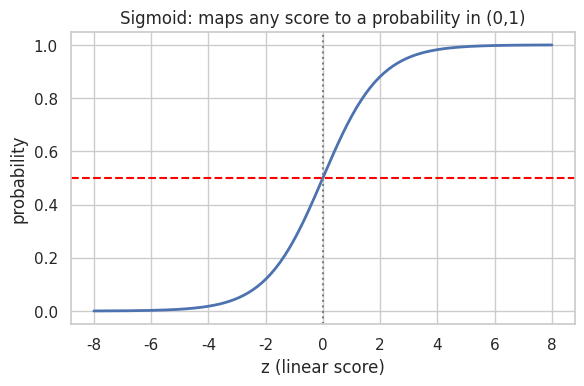

In [2]:
z = np.linspace(-8, 8, 200)
plt.figure(figsize=(6.5,3.8))
plt.plot(z, 1/(1+np.exp(-z)), lw=2)
plt.axhline(0.5, color="red", ls="--"); plt.axvline(0, color="gray", ls=":")
plt.title("Sigmoid: maps any score to a probability in (0,1)")
plt.xlabel("z (linear score)"); plt.ylabel("probability"); plt.show()

In [3]:
features = ["age", "income", "tenure_months", "monthly_spend", "support_calls"]
X = df[features]; y = df["churn"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=42, stratify=y)
scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

logit = LogisticRegression(max_iter=1000).fit(X_tr_s, y_tr)

coef = pd.Series(logit.coef_[0], index=features).sort_values(key=abs, ascending=False)
print("log-odds coefficients (standardized):")
print(coef.round(3))

log-odds coefficients (standardized):
income          -0.694
support_calls    0.635
tenure_months   -0.615
monthly_spend   -0.227
age             -0.006
dtype: float64


**Interpretation:** positive coefficient → raises churn probability. Expect
`support_calls` positive and `tenure_months` negative — matching the data's design
and our EDA. `stratify=y` keeps the class ratio identical in train/test, which
matters when classes are imbalanced.

## 7.2 KNN — "you are the company you keep"

KNN stores the training data and classifies a new point by **majority vote of its
k nearest neighbors** (by distance, usually Euclidean). No training equation — it's
a **lazy learner**. Two consequences:

- **Scaling is mandatory**: distances are dominated by large-range features
  otherwise. (This is the concrete payoff of Module 05.)
- **k controls bias–variance**: small k = wiggly boundary (low bias, high
  variance, overfits); large k = smooth boundary (higher bias, lower variance).

In [4]:
# Show that scaling changes KNN accuracy meaningfully
knn_unscaled = KNeighborsClassifier(n_neighbors=15).fit(X_tr, y_tr)
knn_scaled   = KNeighborsClassifier(n_neighbors=15).fit(X_tr_s, y_tr)
print("KNN accuracy WITHOUT scaling:", round(knn_unscaled.score(X_te, y_te), 3))
print("KNN accuracy WITH    scaling:", round(knn_scaled.score(X_te_s, y_te), 3))

KNN accuracy WITHOUT scaling: 0.68
KNN accuracy WITH    scaling: 0.728


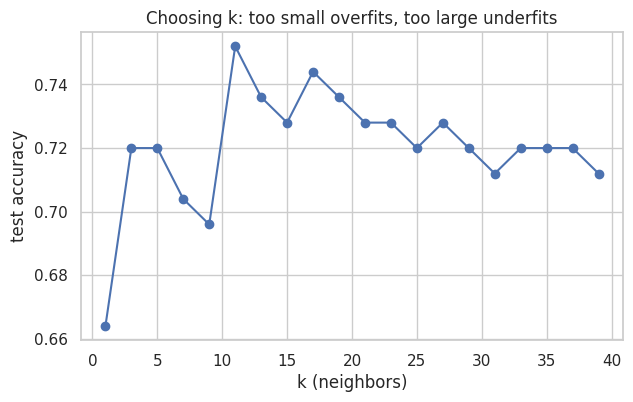

In [5]:
# Effect of k on accuracy (the bias-variance knob)
ks = range(1, 40, 2)
acc = [KNeighborsClassifier(n_neighbors=k).fit(X_tr_s, y_tr).score(X_te_s, y_te)
       for k in ks]
plt.figure(figsize=(7,4))
plt.plot(list(ks), acc, marker="o")
plt.xlabel("k (neighbors)"); plt.ylabel("test accuracy")
plt.title("Choosing k: too small overfits, too large underfits"); plt.show()

## 7.2b KNN, deeper — distance metrics, weighting, regression, the curse

**(1) Distance metric** — "nearest" depends on how you measure distance. KNN's
`metric`/`p` parameter controls this:
- **Euclidean** (`p=2`, default): straight-line distance. The usual choice.
- **Manhattan** (`p=1`): sum of absolute differences ("city-block"). More robust to
  outliers and often better in **high dimensions**.
- **Minkowski**: the general form; `p=1`→Manhattan, `p=2`→Euclidean. sklearn's
  default is Minkowski with `p=2`.

**(2) Weighting** — `weights="uniform"` (all k neighbors vote equally) vs
`weights="distance"` (closer neighbors get **more** vote). Distance-weighting helps
when clusters overlap.

In [6]:
from sklearn.model_selection import cross_val_score

for metric, p in [("euclidean", 2), ("manhattan", 1)]:
    for w in ["uniform", "distance"]:
        clf = KNeighborsClassifier(n_neighbors=15, weights=w, p=p)
        s = cross_val_score(clf, X_tr_s, y_tr, cv=5, scoring="f1").mean()
        print(f"metric={metric:9s} weights={w:8s} -> CV F1 = {s:.3f}")

metric=euclidean weights=uniform  -> CV F1 = 0.373
metric=euclidean weights=distance -> CV F1 = 0.369
metric=manhattan weights=uniform  -> CV F1 = 0.277
metric=manhattan weights=distance -> CV F1 = 0.335


**(3) KNN also does regression.** Instead of a majority *vote*, `KNeighborsRegressor`
**averages** the target of the k nearest neighbors. Same geometry, continuous output.

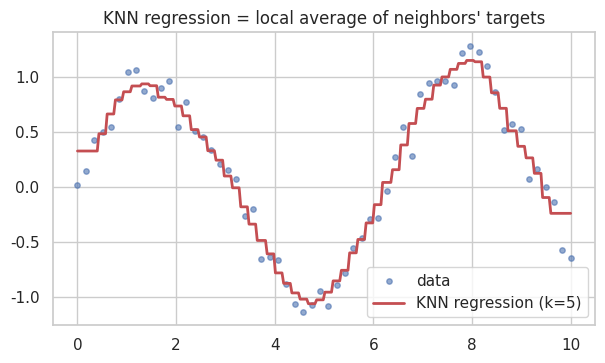

In [7]:
from sklearn.neighbors import KNeighborsRegressor
# tiny 1-D demo: predict y from x by averaging nearest neighbors' y
xr = np.linspace(0, 10, 60)
yr = np.sin(xr) + np.random.default_rng(0).normal(0, 0.15, xr.size)
knr = KNeighborsRegressor(n_neighbors=5).fit(xr.reshape(-1,1), yr)
grid = np.linspace(0, 10, 300).reshape(-1,1)
plt.figure(figsize=(7,3.8))
plt.scatter(xr, yr, s=15, alpha=0.6, label="data")
plt.plot(grid, knr.predict(grid), "r-", lw=2, label="KNN regression (k=5)")
plt.title("KNN regression = local average of neighbors' targets")
plt.legend(); plt.show()

**(4) The curse of dimensionality — KNN's Achilles heel.** As the number of
features grows, points become **almost equidistant** from each other, so "nearest
neighbor" loses meaning and KNN degrades. The demo below shows the ratio of nearest
to farthest distance heading toward 1 as dimensions increase.

In [8]:
rng = np.random.default_rng(0)
print(f"{'dims':>5} {'min_dist':>9} {'max_dist':>9} {'min/max':>8}")
for d in [2, 5, 20, 100, 500]:
    pts = rng.random((500, d))
    from scipy.spatial.distance import pdist
    dd = pdist(pts)
    print(f"{d:5d} {dd.min():9.3f} {dd.max():9.3f} {dd.min()/dd.max():8.3f}")
print("\nAs dims grow, min/max -> 1: all points look equally far => KNN struggles.")
print("Fixes: reduce dimensions (PCA, feature selection) or use Manhattan distance.")

 dims  min_dist  max_dist  min/max
    2     0.002     1.364    0.002
    5     0.076     1.849    0.041
   20     0.771     2.957    0.261
  100     3.037     5.044    0.602
  500     7.963    10.152    0.784

As dims grow, min/max -> 1: all points look equally far => KNN struggles.
Fixes: reduce dimensions (PCA, feature selection) or use Manhattan distance.


## 7.3 Why accuracy is a TRAP on imbalanced data

If 95% of customers don't churn, a model that predicts "no churn" for everyone
scores **95% accuracy** while being **useless** (it never catches a churner). You
must look deeper — at the **confusion matrix**.

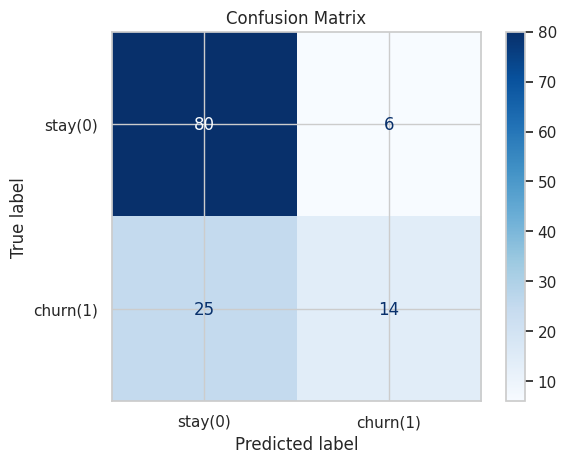

TN=80  FP=6  FN=25  TP=14
precision=0.700  recall/sensitivity=0.359  specificity=0.930  F1=0.475


In [9]:
pred = logit.predict(X_te_s)
cm = confusion_matrix(y_te, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["stay(0)", "churn(1)"])
disp.plot(cmap="Blues", values_format="d"); plt.title("Confusion Matrix"); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

precision   = tp / (tp + fp) if (tp+fp) else 0
recall      = tp / (tp + fn) if (tp+fn) else 0   # = sensitivity / TPR
specificity = tn / (tn + fp) if (tn+fp) else 0   # = TNR
f1          = 2*precision*recall/(precision+recall) if (precision+recall) else 0
print(f"precision={precision:.3f}  recall/sensitivity={recall:.3f}  "
      f"specificity={specificity:.3f}  F1={f1:.3f}")

**Confusion matrix vocabulary (memorize):**
- **TP** true positive — predicted churn, actually churned. ✅
- **TN** true negative — predicted stay, actually stayed. ✅
- **FP** false positive (Type I) — predicted churn, actually stayed. (false alarm)
- **FN** false negative (Type II) — predicted stay, actually churned. (missed it)

From these:
- **Precision** = TP / (TP+FP) — *of those we flagged, how many were right?*
- **Recall** (a.k.a. **Sensitivity**, TPR) = TP / (TP+FN) — *of all real churners,
  how many did we catch?*
- **Specificity** (TNR) = TN / (TN+FP) — *of all real non-churners, how many did we
  correctly clear?* (recall for the negative class; 1 − specificity = FPR, the ROC
  x-axis).
- **F1** = harmonic mean of precision & recall — one balanced number. Harmonic (not
  plain) mean punishes imbalance: F1 is only high when **both** are high.

In [10]:
print(classification_report(y_te, pred, target_names=["stay", "churn"]))

              precision    recall  f1-score   support

        stay       0.76      0.93      0.84        86
       churn       0.70      0.36      0.47        39

    accuracy                           0.75       125
   macro avg       0.73      0.64      0.66       125
weighted avg       0.74      0.75      0.72       125



**Precision vs recall — a business decision, not a math one:**
- Fraud / disease / churn-you-must-catch → prioritize **recall** (don't miss
  positives), accept more false alarms.
- Spam filter / flagging for expensive manual review → prioritize **precision**
  (don't cry wolf).

You move along this tradeoff by changing the **decision threshold** (default 0.5).

## 7.4 ROC curve & AUC — threshold-free evaluation

The **ROC curve** plots True Positive Rate (recall) vs False Positive Rate across
*all* thresholds. **AUC** (area under it) summarizes ranking quality in `[0.5, 1]`:
0.5 = random, 1.0 = perfect. AUC answers "how well does the model *rank* a random
positive above a random negative?" — independent of any single threshold.

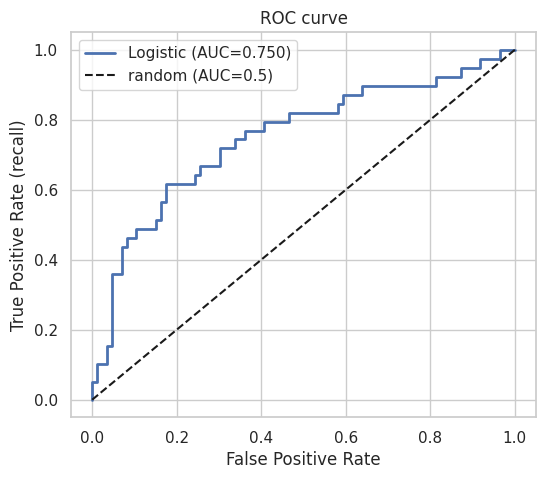

In [11]:
proba = logit.predict_proba(X_te_s)[:, 1]       # P(churn)
fpr, tpr, thr = roc_curve(y_te, proba)
auc = roc_auc_score(y_te, proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"Logistic (AUC={auc:.3f})")
plt.plot([0,1], [0,1], "k--", label="random (AUC=0.5)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate (recall)")
plt.title("ROC curve"); plt.legend(); plt.show()

In [12]:
# Tuning the threshold to hit a recall target (e.g. catch >=70% of churners)
prec, rec, thresholds = precision_recall_curve(y_te, proba)
target_recall = 0.70
idx = np.argmin(np.abs(rec[:-1] - target_recall))
chosen = thresholds[idx]
print(f"To reach ~{target_recall:.0%} recall, set threshold ≈ {chosen:.2f}")
new_pred = (proba >= chosen).astype(int)
print(classification_report(y_te, new_pred, target_names=["stay","churn"]))

To reach ~70% recall, set threshold ≈ 0.33
              precision    recall  f1-score   support

        stay       0.83      0.70      0.76        86
       churn       0.51      0.69      0.59        39

    accuracy                           0.70       125
   macro avg       0.67      0.69      0.67       125
weighted avg       0.73      0.70      0.71       125



## 7.5 Handling class imbalance (the honest toolkit)

Options, roughly in order of preference:
1. **Use the right metric** (F1, recall, AUC, PR-AUC) — never accuracy alone.
2. **`class_weight="balanced"`** — tells the model to care more about the rare
   class (reweights the loss). Cheap and effective.
3. **Resampling** — oversample the minority (e.g. SMOTE) or undersample majority.
   Do it **inside** cross-validation folds to avoid leakage.
4. **Adjust the threshold** to the business cost of FP vs FN.

In [13]:
balanced = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_tr_s, y_tr)
bal_pred = balanced.predict(X_te_s)
print("With class_weight='balanced':")
print(classification_report(y_te, bal_pred, target_names=["stay","churn"]))

With class_weight='balanced':
              precision    recall  f1-score   support

        stay       0.85      0.70      0.76        86
       churn       0.52      0.72      0.60        39

    accuracy                           0.70       125
   macro avg       0.68      0.71      0.68       125
weighted avg       0.74      0.70      0.71       125



Compare this report to the earlier one: recall on the churn class typically rises
(we catch more churners) at some cost to precision. **That is the tradeoff made
explicit** — and being able to explain it is what interviewers want.

## 7.6 Mini-exercises

1. Fit KNN with the best k from the curve; compare its F1 to logistic regression.
2. Find the threshold that **maximizes F1** for the logistic model.
3. Explain to a manager the difference between precision and recall using the
   churn example.
4. When would a 99% accuracy model be *worse* than a 80% accuracy one?

## Summary

- **Logistic regression**: linear score → sigmoid → probability; coefficients are
  log-odds. **KNN**: majority vote of nearest neighbors; **must scale**; k is the
  bias–variance knob.
- **Accuracy is misleading** under imbalance — use the **confusion matrix**.
- **Precision** (of flagged, how many right) vs **recall** (of real positives, how
  many caught); **F1** balances them.
- **ROC/AUC** evaluate ranking across all thresholds; tune the **threshold** to the
  business cost.
- Fight imbalance with metrics, `class_weight`, resampling, thresholding.

Next: **Module 08 — Evaluation, Cross-Validation & Grid Search** (doing all this
without fooling yourself).